# Optimizer profile: scaling with model size
Step time and peak memory against parameter count $P$, Sven against the baselines. Two families: the 3-hidden-layer MNIST MLP (width 32 to 2048) and the 4-layer nanoGPT (embedding width 64 to 512). Red crosses mark the first size at which a method ran out of memory or was analytically infeasible.

In [1]:
import sys
sys.path.insert(0, '.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from style import set_style
import profile_helpers as ph
set_style()
PLOT_DIR = 'plots_v2/profile'
# $SV3_PROFILE_ROOT > profile_results_v3 (the re-measured profile) > profile_results_v2
ROOT = ph.results_root()         # prints which root it chose
df = ph.load_profiles(ROOT)      # one tidy row per configuration
ARCHS = [a for a in ph.ARCH_ORDER if a in set(df.arch)]
df.groupby(['arch', 'study']).size().unstack(fill_value=0)
WIDTH = [a for a in ['mnist_width', 'nanogpt_width'] if a in set(df.arch)]

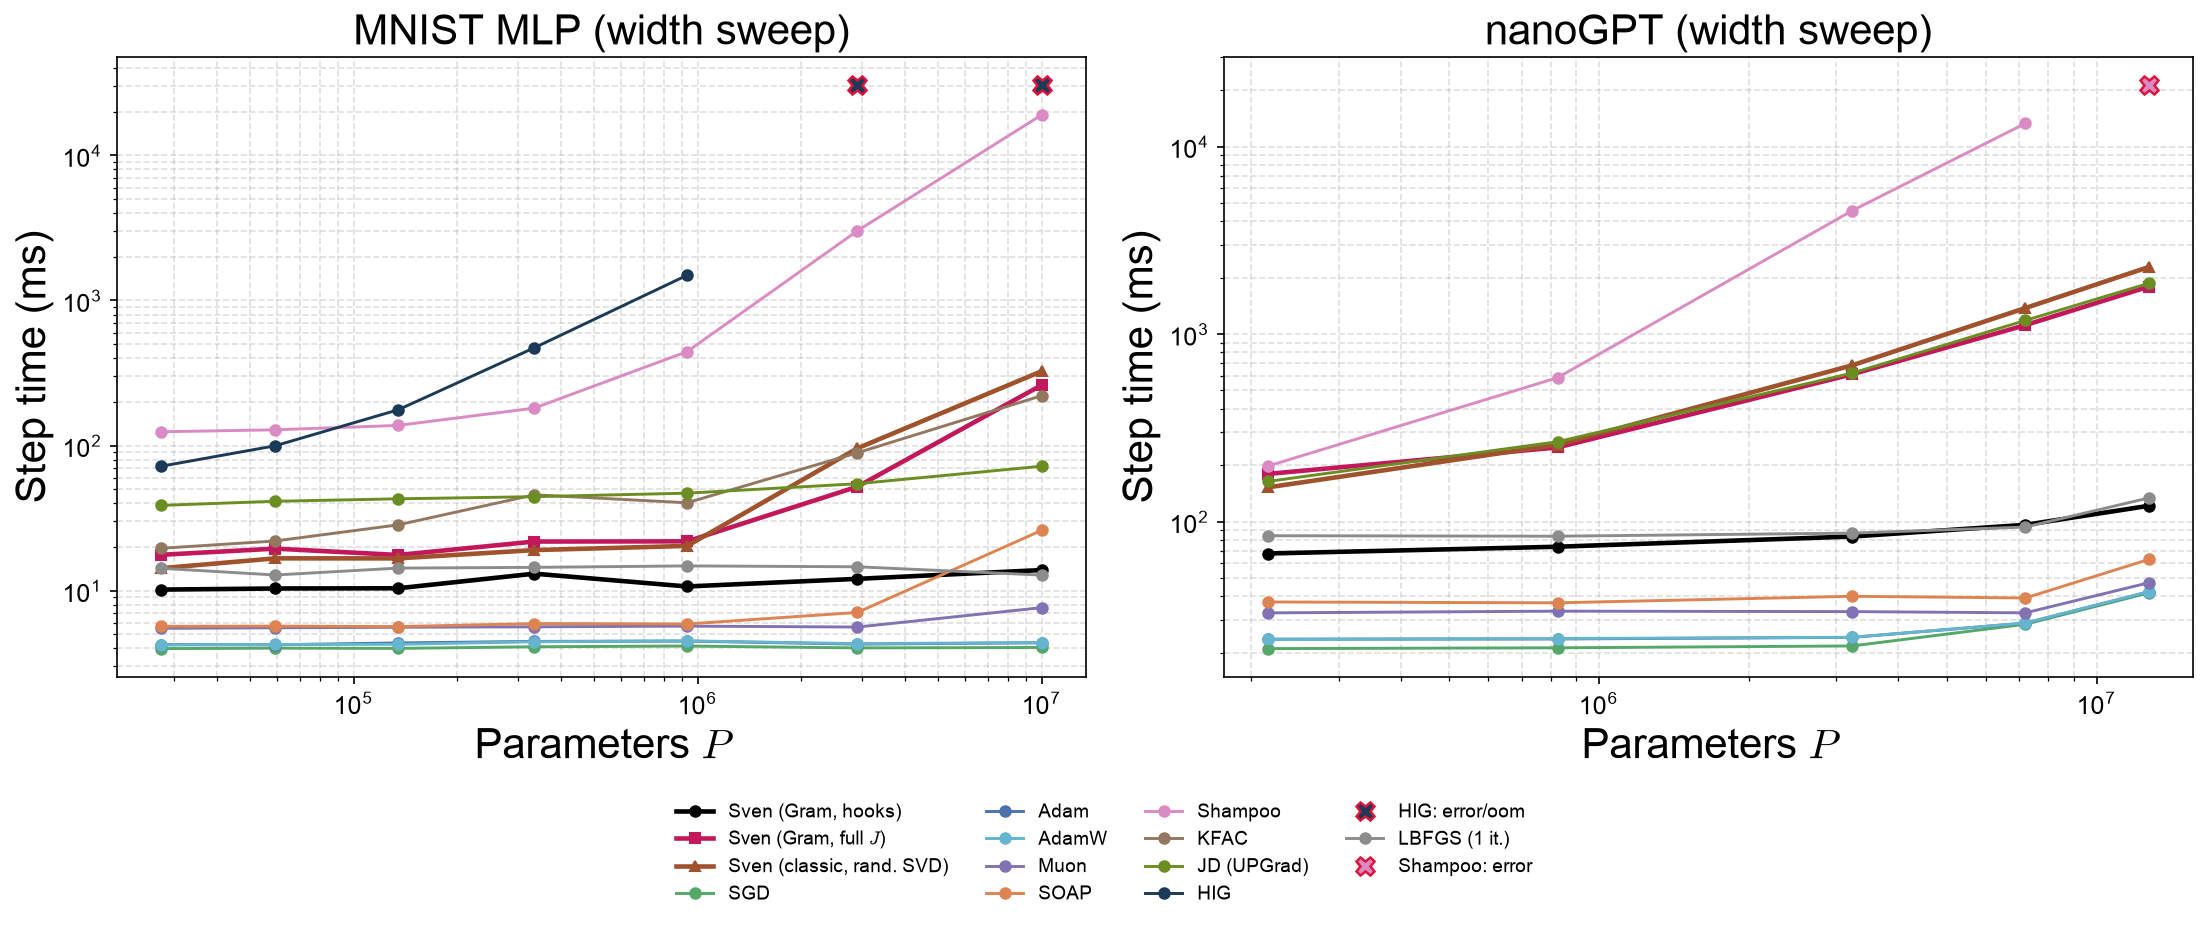

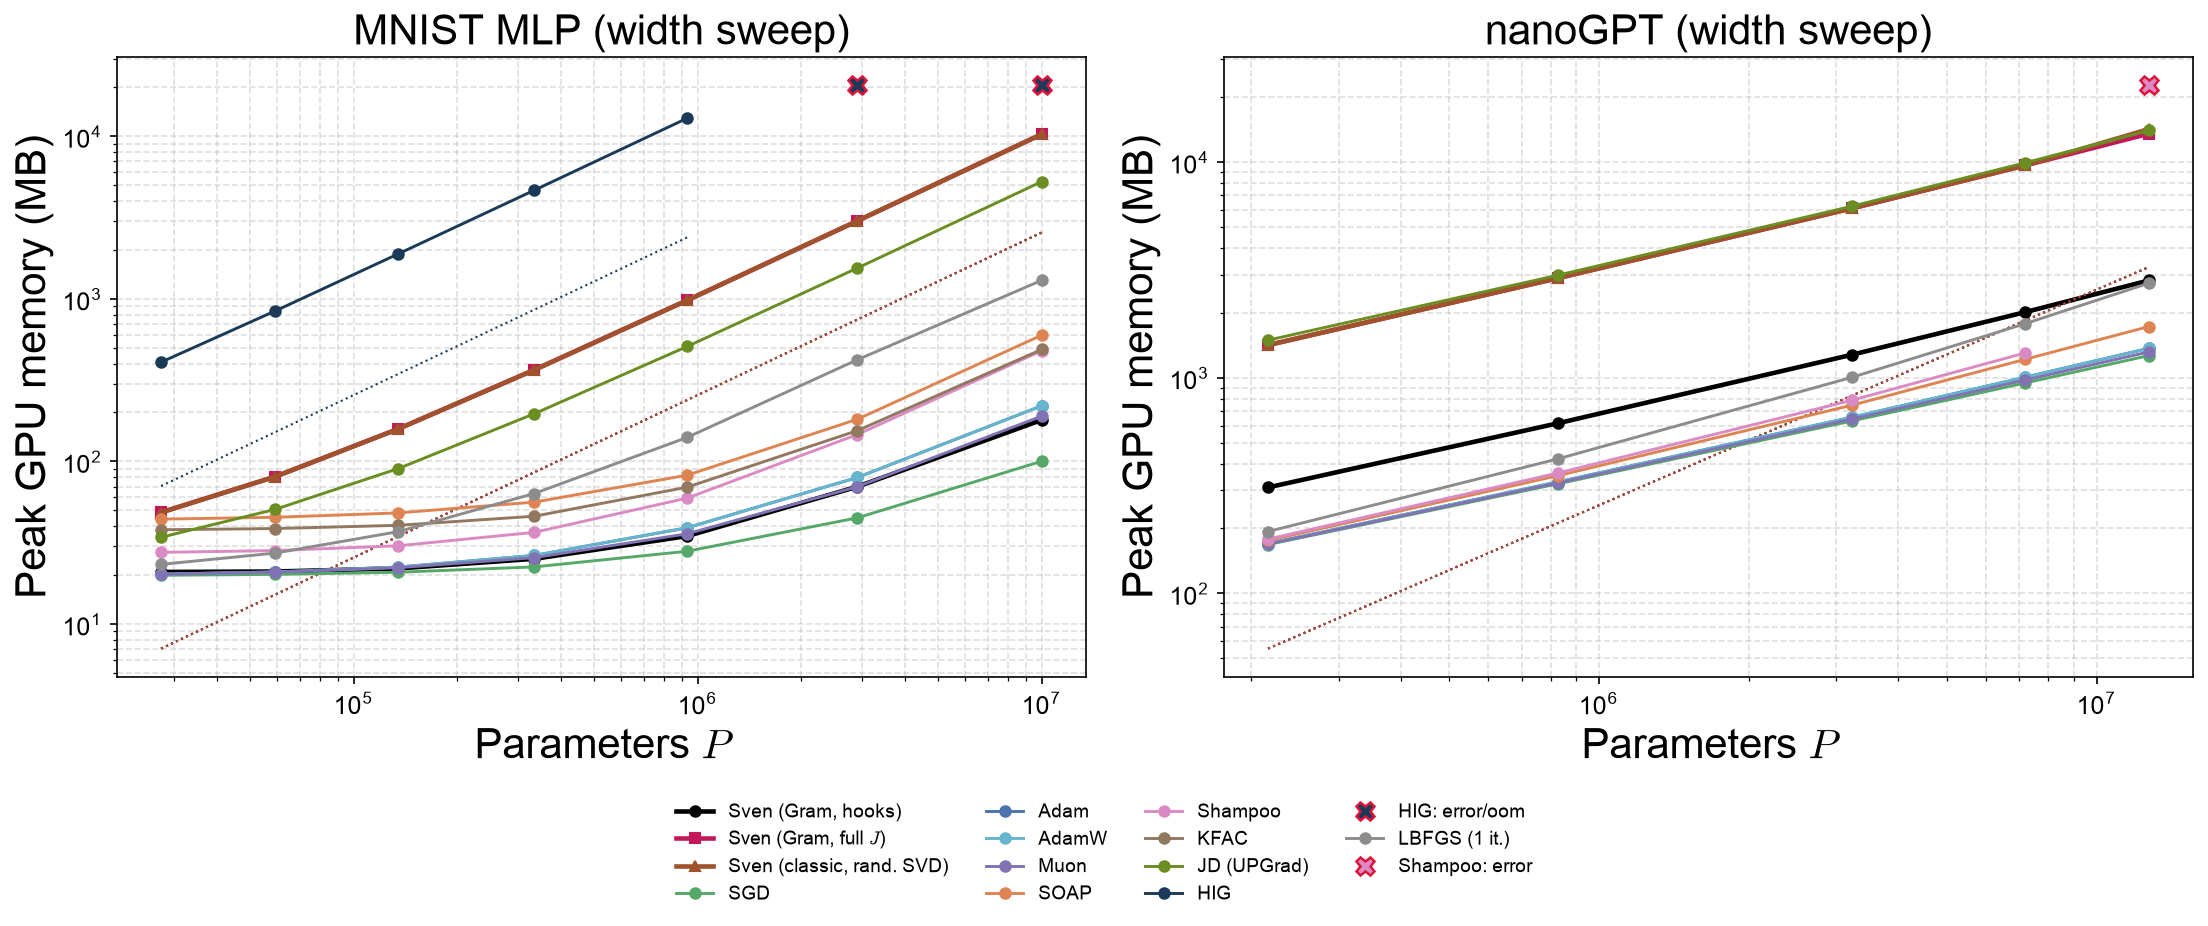

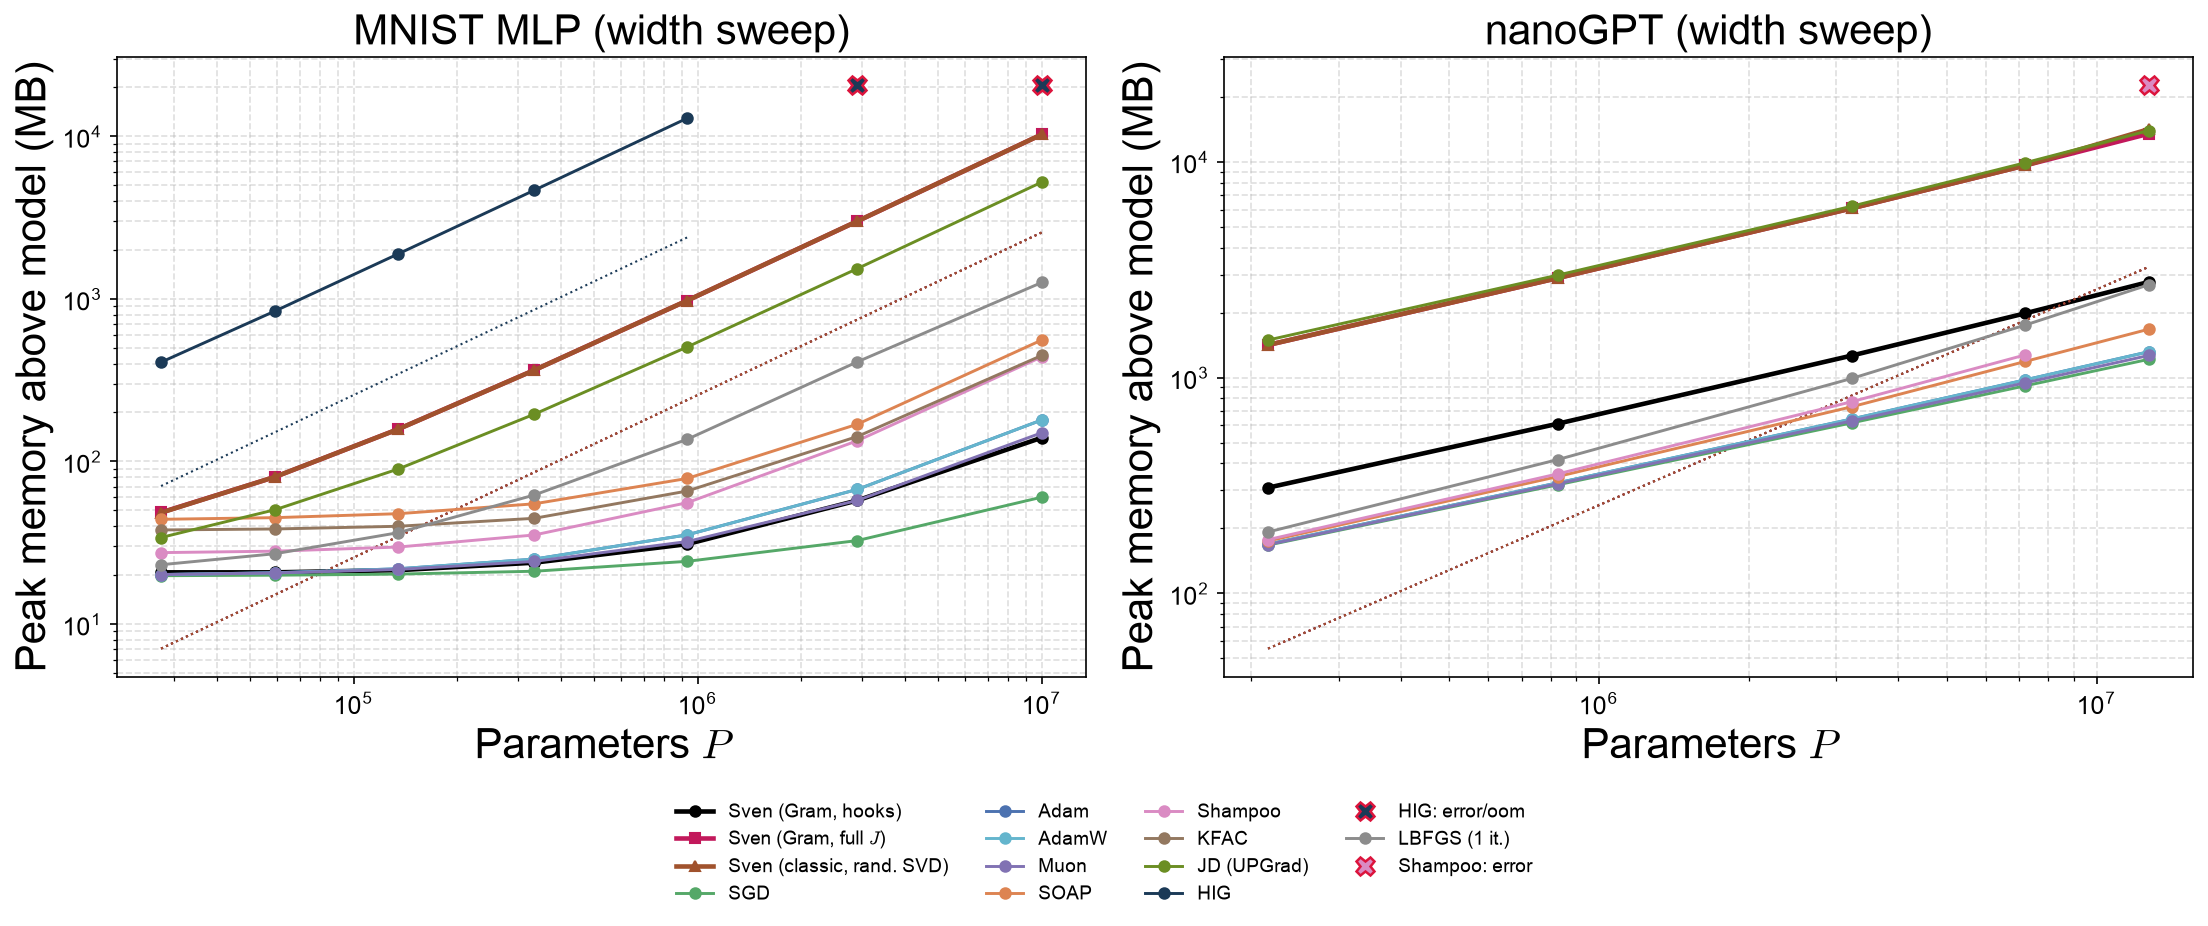

In [2]:
for value, fname in [('step_ms', 'scaling_step_time'), ('peak_mb', 'scaling_peak_memory'), ('overhead_mb', 'scaling_memory_overhead')]:
    fig, axes = plt.subplots(1, len(WIDTH), figsize=(7.5 * len(WIDTH), 5.5), squeeze=False)
    for ax, arch in zip(axes[0], WIDTH):
        ph.plot_sweep(df, arch, 'width', 'n_params', ax, value=value, analytic='analytic_jac_mb' if value != 'step_ms' else None)
        ax.set_xscale('log')
    ph.legend_below(fig, axes[0][0])
    fig.tight_layout(); ph.save(fig, f'{fname}.pdf', PLOT_DIR); plt.show()

### Sven variants only
The Gram/hooks path never forms the Jacobian, so its memory should track the model; the full-Jacobian paths carry the $B P\cdot 4$-byte block (dotted).

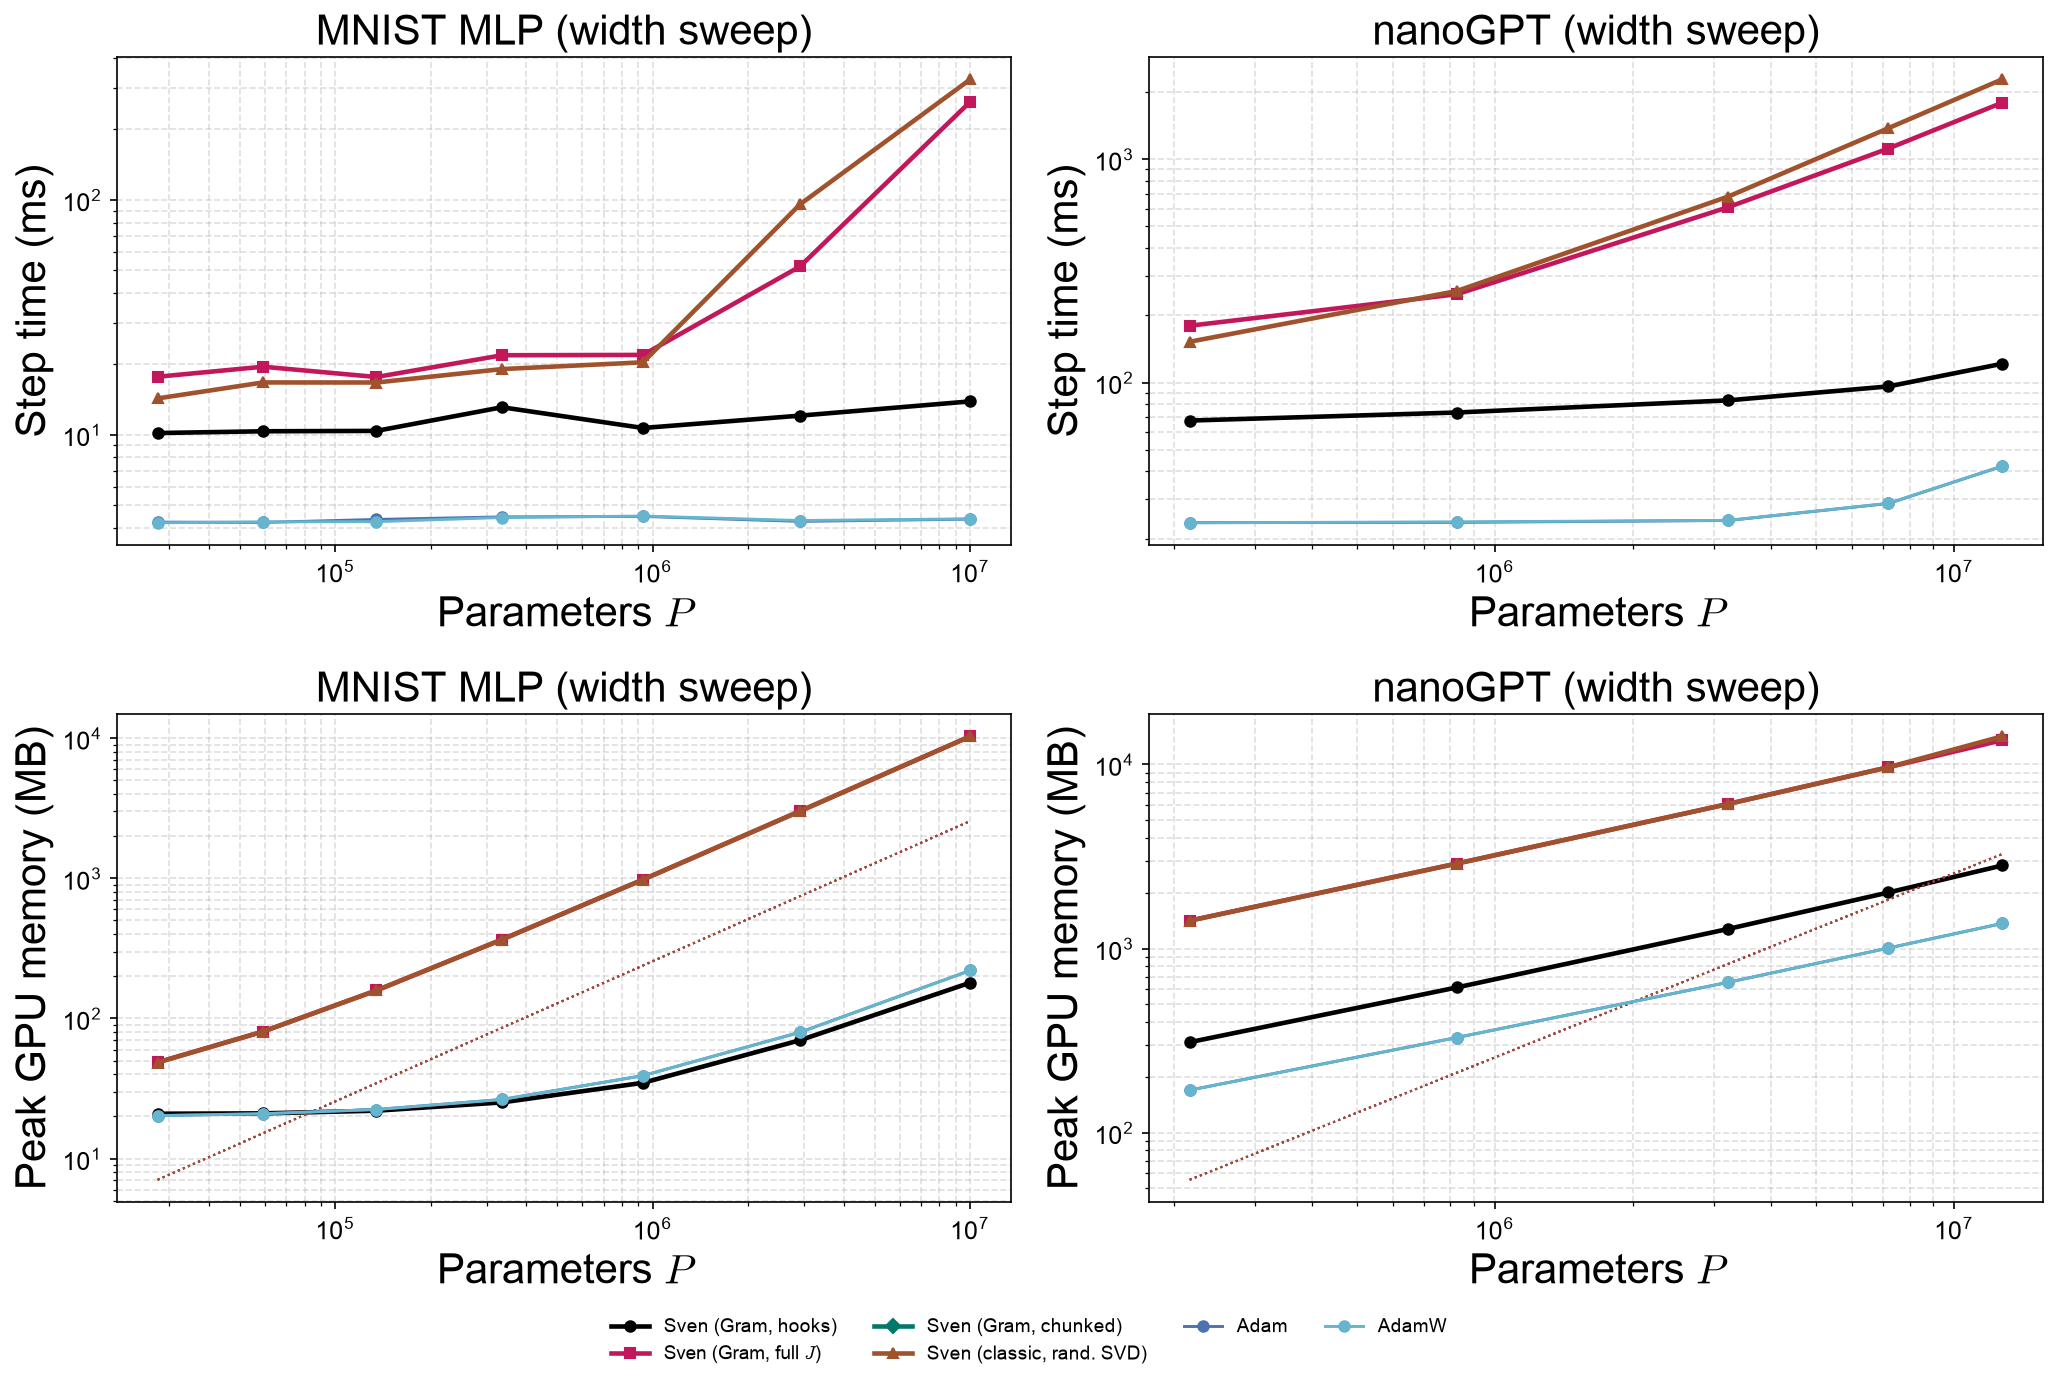

In [3]:
fig, axes = plt.subplots(2, len(WIDTH), figsize=(7 * len(WIDTH), 9), squeeze=False)
for j, arch in enumerate(WIDTH):
    ms = ph.SVEN + ['Adam', 'AdamW']
    ph.plot_sweep(df, arch, 'width', 'n_params', axes[0][j], value='step_ms', methods=ms); axes[0][j].set_xscale('log')
    ph.plot_sweep(df, arch, 'width', 'n_params', axes[1][j], value='peak_mb', methods=ms, analytic='analytic_jac_mb'); axes[1][j].set_xscale('log')
ph.legend_below(fig, axes[0][0])
fig.tight_layout(); ph.save(fig, 'scaling_sven_variants.pdf', PLOT_DIR); plt.show()

### Fitted growth
Exponent of cost in $P$ over the upper half of the size range, and where each method first fails.

In [4]:
for arch in WIDTH:
    for value in ['step_ms', 'peak_mb']:
        t = ph.scaling_table(df, arch, value)
        print(f"\n=== {ph.ARCH_TITLES[arch]}: {value} ==="); display(t)
        t.to_csv(f'{PLOT_DIR}/table_scaling_{arch}_{value}.csv', index=False)


=== MNIST MLP (width sweep): step_ms ===


,Method,smallest P,largest ok P,at largest,growth,exponent,first failure
0,LBFGS (1 it.),14.2,"10,020,874",12.8,0.9,-0.02,
1,Adam,4.24,"10,020,874",4.37,1.0,-0.00,
2,AdamW,4.21,"10,020,874",4.38,1.0,0.00,
3,SGD,3.98,"10,020,874",4.05,1.0,0.00,
4,"Sven (Gram, hooks)",10.2,"10,020,874",13.9,1.4,0.05,
5,Muon,5.49,"10,020,874",7.63,1.4,0.06,
6,JD (UPGrad),38.7,"10,020,874",72,1.9,0.12,
7,SOAP,5.67,"10,020,874",26.1,4.6,0.31,
8,KFAC,19.6,"10,020,874",221,11.3,0.45,
9,"Sven (Gram, full $J$)",17.6,"10,020,874",262,14.8,0.60,



=== MNIST MLP (width sweep): peak_mb ===


,Method,smallest P,largest ok P,at largest,growth,exponent,first failure
0,SGD,19.9,"10,020,874",100,5.0,0.36,
1,"Sven (Gram, hooks)",20.9,"10,020,874",180,8.6,0.49,
2,Muon,20.2,"10,020,874",190,9.4,0.50,
3,Adam,20.3,"10,020,874",220,10.9,0.53,
4,AdamW,20.3,"10,020,874",220,10.9,0.53,
5,KFAC,38,"10,020,874",489,12.9,0.58,
6,SOAP,44.2,"10,020,874",599,13.6,0.59,
7,Shampoo,27.6,"10,020,874",480,17.4,0.65,
8,LBFGS (1 it.),23.3,"10,020,874","1,302",56.0,0.84,
9,JD (UPGrad),34.1,"10,020,874","5,271",154.4,0.95,



=== nanoGPT (width sweep): step_ms ===


,Method,smallest P,largest ok P,at largest,growth,exponent,first failure
0,Muon,32.6,"12,742,656",47.2,1.4,0.09,
1,LBFGS (1 it.),84.1,"12,742,656",134,1.6,0.14,
2,SOAP,37.3,"12,742,656",62.9,1.7,0.15,
3,"Sven (Gram, hooks)",67.6,"12,742,656",121,1.8,0.17,
4,Adam,23.6,"12,742,656",42.2,1.8,0.19,
5,AdamW,23.6,"12,742,656",42.3,1.8,0.19,
6,SGD,21,"12,742,656",41.7,2.0,0.23,
7,JD (UPGrad),164,"12,742,656","1,866",11.4,0.71,
8,"Sven (Gram, full $J$)",180,"12,742,656","1,791",10.0,0.72,
9,"Sven (classic, rand. SVD)",152,"12,742,656","2,279",15.0,0.80,



=== nanoGPT (width sweep): peak_mb ===


,Method,smallest P,largest ok P,at largest,growth,exponent,first failure
0,SGD,168,"12,742,656","1,267",7.5,0.50,
1,Muon,169,"12,742,656","1,318",7.8,0.51,
2,Adam,170,"12,742,656","1,369",8.0,0.52,
3,AdamW,170,"12,742,656","1,369",8.0,0.52,
4,JD (UPGrad),"1,493","12,742,656","14,011",9.4,0.56,
5,"Sven (Gram, full $J$)","1,417","12,742,656","13,545",9.6,0.56,
6,"Sven (Gram, hooks)",310,"12,742,656","2,826",9.1,0.56,
7,SOAP,176,"12,742,656","1,728",9.8,0.58,
8,"Sven (classic, rand. SVD)","1,417","12,742,656","14,223",10.0,0.58,
9,Shampoo,178,"7,197,696","1,304",7.3,0.59,"error @ P=12,742,656"


### Relative to Adam

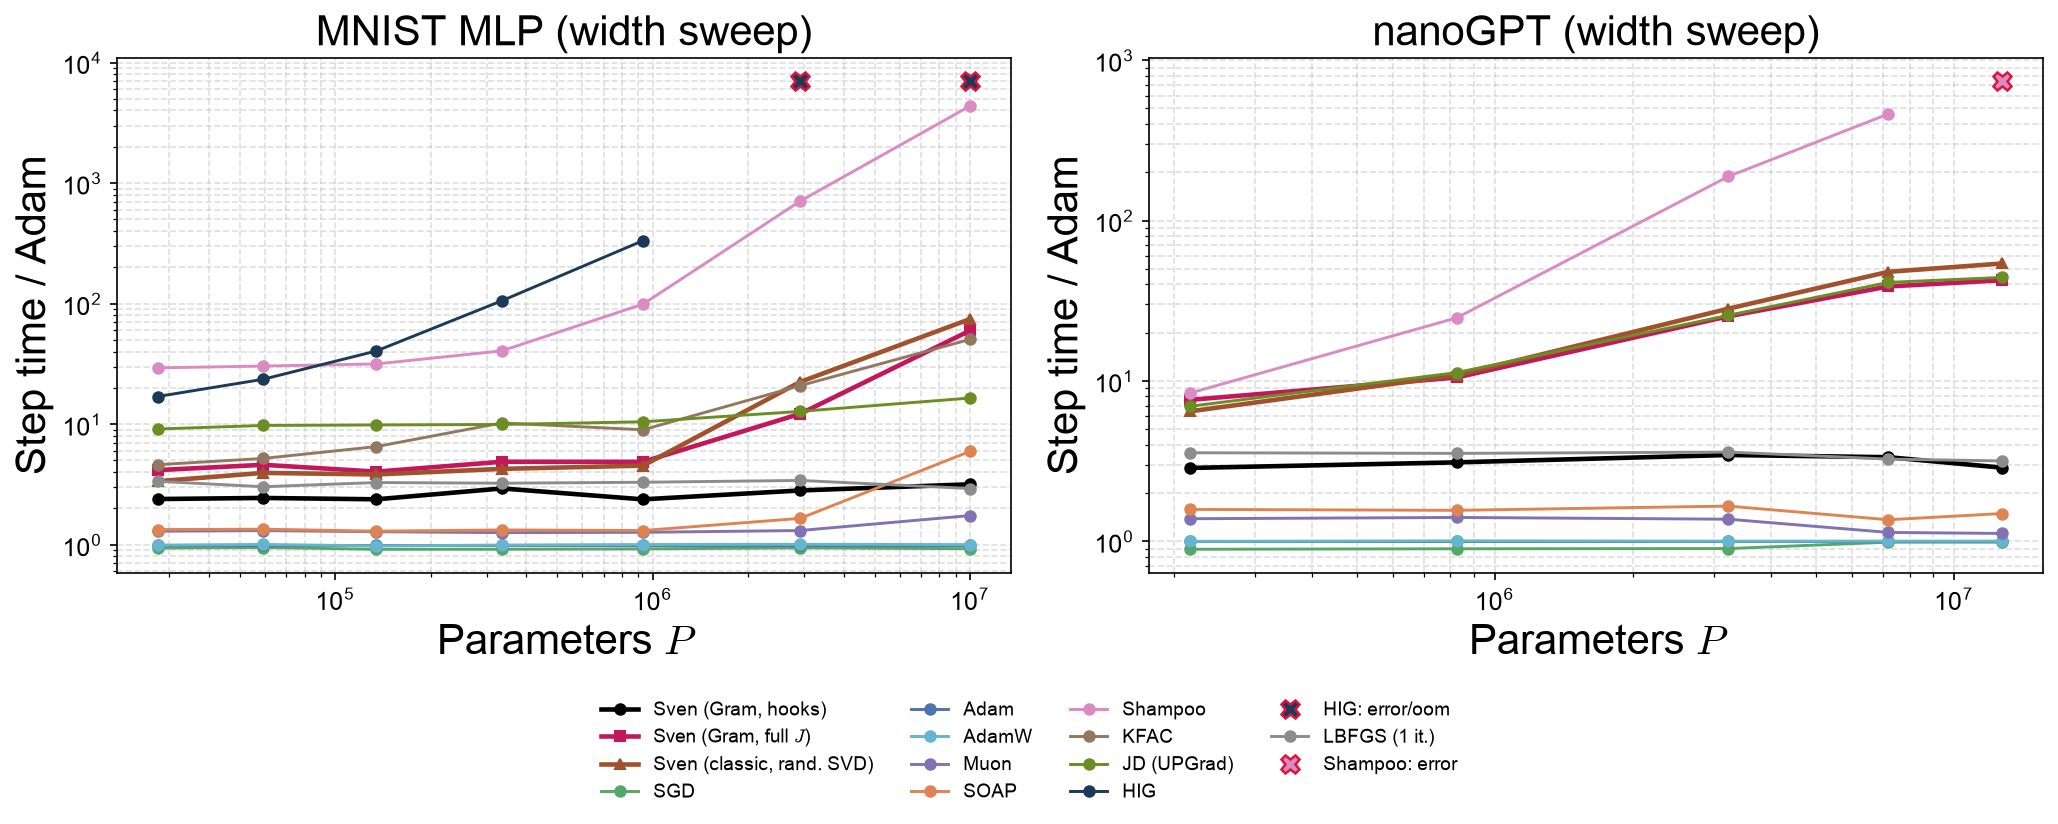

In [5]:
fig, axes = plt.subplots(1, len(WIDTH), figsize=(7 * len(WIDTH), 4.8), squeeze=False)
for ax, arch in zip(axes[0], WIDTH):
    ph.plot_sweep(df, arch, 'width', 'n_params', ax, value='rel_time'); ax.set_xscale('log'); ax.set_ylabel('Step time / Adam')
ph.legend_below(fig, axes[0][0])
fig.tight_layout(); ph.save(fig, 'scaling_relative_to_adam.pdf', PLOT_DIR); plt.show()